# Customer Churn Prediction Using Machine Learning
**Course:** Artificial Intelligence | **University of Lahore** | Faculty of Information Technology

**Goal:** Predict whether a telecom customer will leave the company (`Churn = Yes`) or stay (`Churn = No`).

**Pipeline:** Load data -> Clean -> EDA -> Feature engineering & encoding -> Train models -> Evaluate -> Predict on new customers.

## Step 1: Data Loading and Understanding

In [1]:
import warnings, os
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_auc_score,
                             classification_report, ConfusionMatrixDisplay)

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 50)
print("Libraries imported successfully")

Libraries imported successfully


In [2]:
# Load the dataset (Excel version if available, otherwise the CSV version of the same data)
xlsx_path = "WA_Fn-UseC_-Telco-Customer-Churn.xlsx"
csv_path  = "WA_Fn-UseC_-Telco-Customer-Churn.csv"
if os.path.exists(xlsx_path):
    df = pd.read_excel(xlsx_path)
else:
    df = pd.read_csv(csv_path)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print("Shape (rows, columns):", df.shape)
print()
print("Column names:")
print(list(df.columns))

Shape (rows, columns): (7043, 21)

Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
# The target variable
print("Target variable: Churn")
print(df["Churn"].value_counts())

Target variable: Churn
Churn
No     5174
Yes    1869
Name: count, dtype: int64


### What the important columns mean
| Column | Meaning (simple words) |
|---|---|
| `customerID` | Unique ID of each customer (just a label, not useful for prediction) |
| `gender`, `SeniorCitizen`, `Partner`, `Dependents` | Basic customer profile (sex, age 65+, has partner, has dependents) |
| `tenure` | How many **months** the customer has been with the company |
| `PhoneService`, `MultipleLines` | Whether the customer has phone service / more than one line |
| `InternetService` | Type of internet: DSL, Fiber optic, or No |
| `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies` | Extra add-on services the customer has taken |
| `Contract` | Month-to-month, One year, or Two year contract |
| `PaperlessBilling`, `PaymentMethod` | How the customer receives the bill and pays it |
| `MonthlyCharges` | Amount the customer pays every month |
| `TotalCharges` | Total amount paid so far |
| **`Churn`** | **TARGET:** did the customer leave? (Yes / No) |

## Step 2: Data Preprocessing

In [7]:
# 2.1 Missing values
print("Missing values per column (NaN):")
print(df.isnull().sum().sum(), "total NaN found")
print()
# 2.2 Duplicate records
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate customerIDs:", df["customerID"].duplicated().sum())

Missing values per column (NaN):
0 total NaN found

Duplicate rows: 0
Duplicate customerIDs: 0


No `NaN` values and no duplicates were found. But `TotalCharges` is stored as **text (object)** even though it is a number.
That usually means some cells contain blank spaces, so pandas could not read them as numbers. Let us check.

In [8]:
print("TotalCharges dtype:", df["TotalCharges"].dtype)
blank = df["TotalCharges"].astype(str).str.strip() == ""
print("Blank TotalCharges rows:", blank.sum())
df.loc[blank, ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]]

TotalCharges dtype: str
Blank TotalCharges rows: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


All 11 blank rows have `tenure = 0`: these are brand-new customers who have not been billed yet.
So the correct value of `TotalCharges` is **0**. We convert the column to numeric and fill these with 0.

In [9]:
# 2.3 Fix wrong data type
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce").fillna(0)
print("TotalCharges dtype now:", df["TotalCharges"].dtype)

# 2.4 Drop unnecessary column (ID has no predictive meaning)
df = df.drop(columns=["customerID"])

# 2.5 Clean inconsistent categories:
# "No internet service" / "No phone service" already mean "No" (the info is stored in InternetService / PhoneService)
service_cols = ["MultipleLines", "OnlineSecurity", "OnlineBackup", "DeviceProtection",
                "TechSupport", "StreamingTV", "StreamingMovies"]
for c in service_cols:
    df[c] = df[c].replace({"No internet service": "No", "No phone service": "No"})

print("Unique values after cleaning:")
for c in service_cols:
    print(f"  {c:18s}", df[c].unique())

TotalCharges dtype now: float64
Unique values after cleaning:
  MultipleLines      <StringArray>
['No', 'Yes']
Length: 2, dtype: str
  OnlineSecurity     <StringArray>
['No', 'Yes']
Length: 2, dtype: str
  OnlineBackup       <StringArray>
['Yes', 'No']
Length: 2, dtype: str
  DeviceProtection   <StringArray>
['No', 'Yes']
Length: 2, dtype: str
  TechSupport        <StringArray>
['No', 'Yes']
Length: 2, dtype: str
  StreamingTV        <StringArray>
['No', 'Yes']
Length: 2, dtype: str
  StreamingMovies    <StringArray>
['No', 'Yes']
Length: 2, dtype: str


In [10]:
# 2.6 Check class balance and final data quality
print("Any missing values left?", df.isnull().sum().sum())
print("Final shape:", df.shape)
print()
print(df["Churn"].value_counts(normalize=True).round(3) * 100, "(%)")

Any missing values left? 0
Final shape: (7043, 20)

Churn
No     73.5
Yes    26.5
Name: proportion, dtype: float64 (%)


**Why each step was needed**
- *TotalCharges to numeric:* models cannot do maths on text.
- *Fill blanks with 0:* those customers have tenure = 0, so they have paid nothing yet.
- *Drop customerID:* a unique ID would only add noise and could cause overfitting.
- *Merge 'No internet/phone service' into 'No':* they carry the same meaning; keeping them separate creates redundant columns.
- The data is **imbalanced** (about 73% No vs 27% Yes), which we handle later with `class_weight="balanced"`.

## Step 3: Exploratory Data Analysis (EDA)

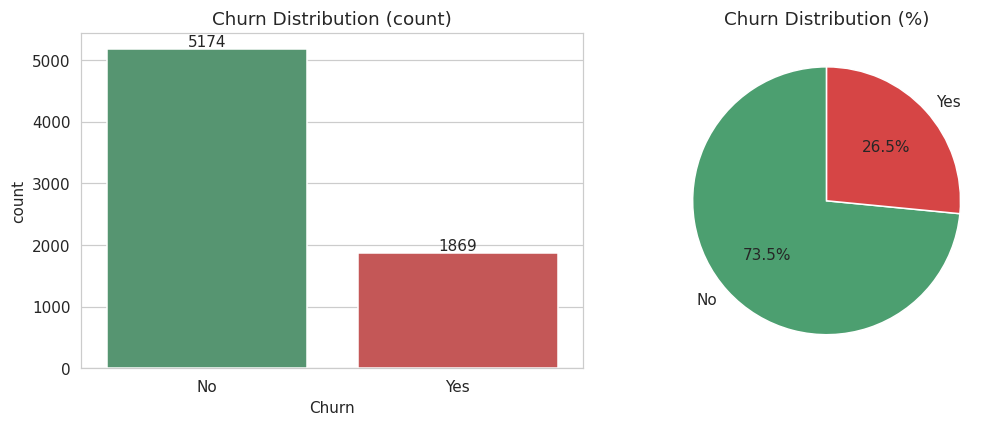

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
counts = df["Churn"].value_counts()
sns.countplot(x="Churn", data=df, palette=["#4C9F70", "#D64545"], ax=ax[0])
ax[0].set_title("Churn Distribution (count)")
for p in ax[0].patches:
    ax[0].annotate(int(p.get_height()), (p.get_x()+p.get_width()/2, p.get_height()), ha="center", va="bottom")
ax[1].pie(counts, labels=counts.index, autopct="%1.1f%%", colors=["#4C9F70", "#D64545"], startangle=90)
ax[1].set_title("Churn Distribution (%)")
plt.tight_layout(); plt.show()

In [12]:
# Churn rate (%) for important categorical columns
for col in ["Contract", "InternetService", "PaymentMethod", "SeniorCitizen"]:
    rate = df.groupby(col)["Churn"].apply(lambda s: (s == "Yes").mean() * 100).round(1)
    print(f"Churn rate by {col} (%)")
    print(rate.to_string())
    print()

Churn rate by Contract (%)
Contract
Month-to-month    42.7
One year          11.3
Two year           2.8

Churn rate by InternetService (%)
InternetService
DSL            19.0
Fiber optic    41.9
No              7.4

Churn rate by PaymentMethod (%)
PaymentMethod
Bank transfer (automatic)    16.7
Credit card (automatic)      15.2
Electronic check             45.3
Mailed check                 19.1

Churn rate by SeniorCitizen (%)
SeniorCitizen
0    23.6
1    41.7



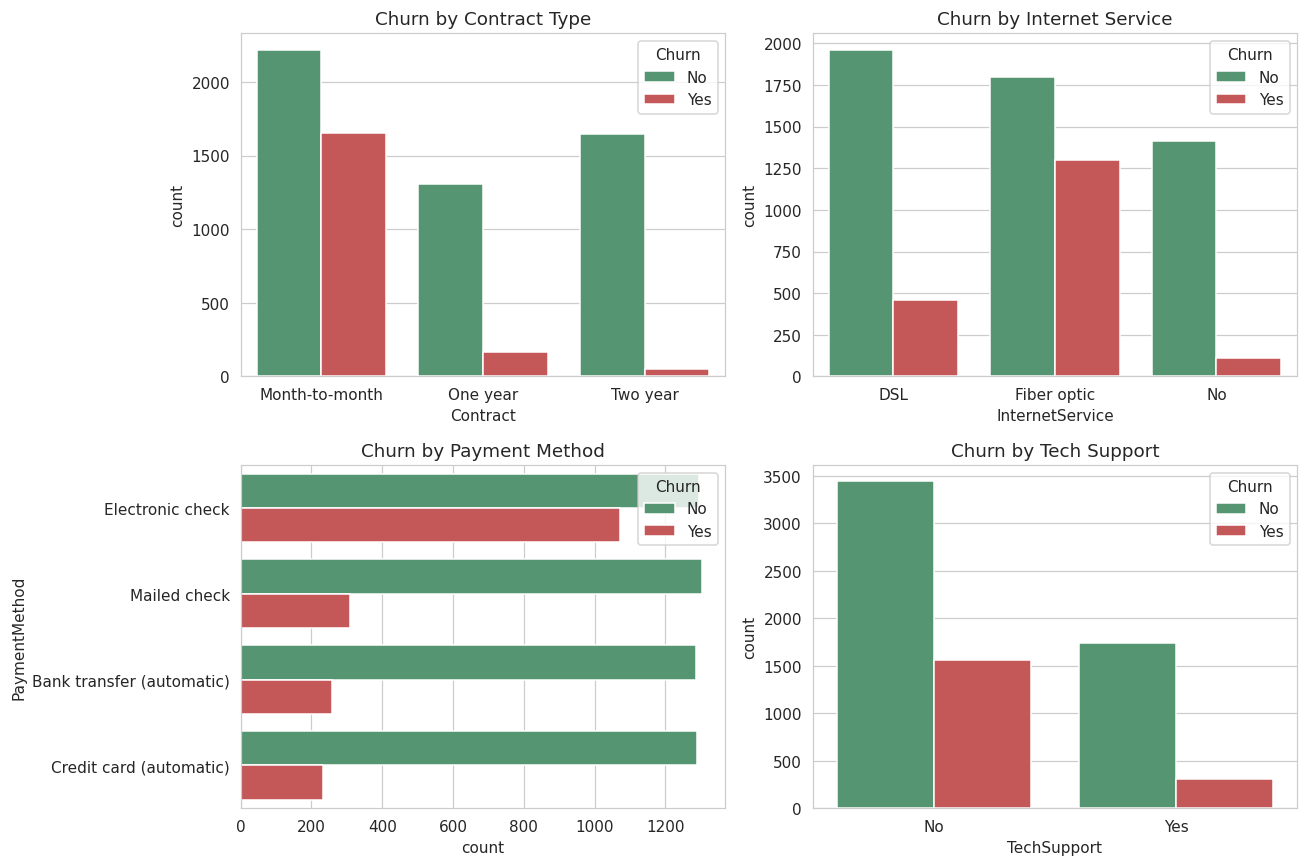

In [13]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
sns.countplot(x="Contract", hue="Churn", data=df, palette=["#4C9F70", "#D64545"], ax=ax[0, 0])
ax[0, 0].set_title("Churn by Contract Type")
sns.countplot(x="InternetService", hue="Churn", data=df, palette=["#4C9F70", "#D64545"], ax=ax[0, 1])
ax[0, 1].set_title("Churn by Internet Service")
sns.countplot(y="PaymentMethod", hue="Churn", data=df, palette=["#4C9F70", "#D64545"], ax=ax[1, 0])
ax[1, 0].set_title("Churn by Payment Method")
sns.countplot(x="TechSupport", hue="Churn", data=df, palette=["#4C9F70", "#D64545"], ax=ax[1, 1])
ax[1, 1].set_title("Churn by Tech Support")
plt.tight_layout(); plt.show()

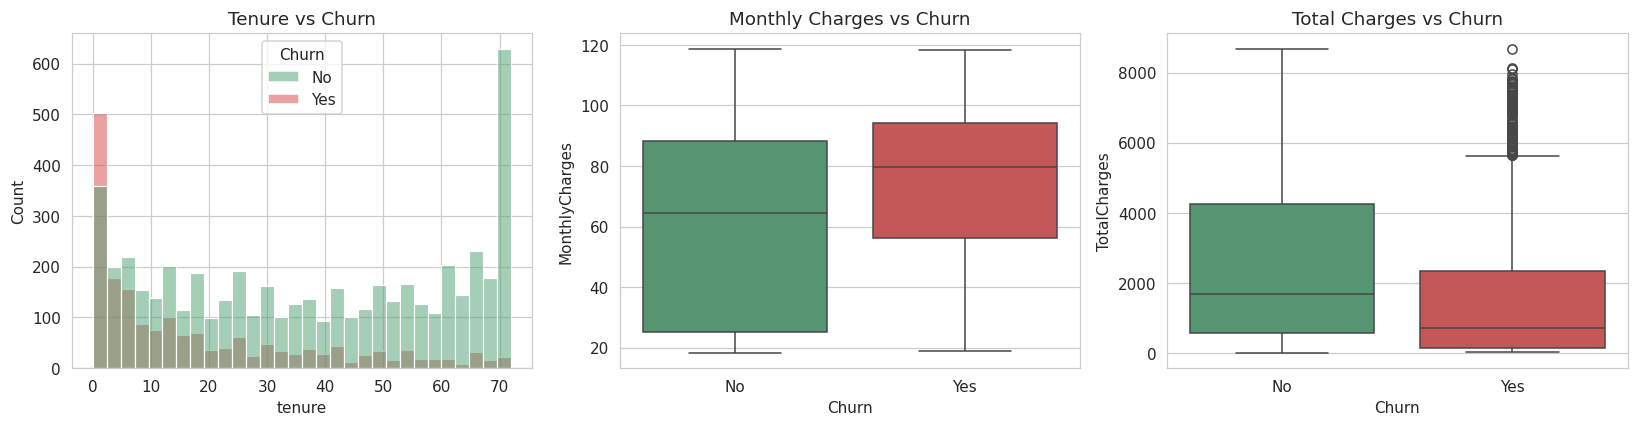

In [14]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(data=df, x="tenure", hue="Churn", bins=30, palette=["#4C9F70", "#D64545"], ax=ax[0])
ax[0].set_title("Tenure vs Churn")
sns.boxplot(x="Churn", y="MonthlyCharges", data=df, palette=["#4C9F70", "#D64545"], ax=ax[1])
ax[1].set_title("Monthly Charges vs Churn")
sns.boxplot(x="Churn", y="TotalCharges", data=df, palette=["#4C9F70", "#D64545"], ax=ax[2])
ax[2].set_title("Total Charges vs Churn")
plt.tight_layout(); plt.show()

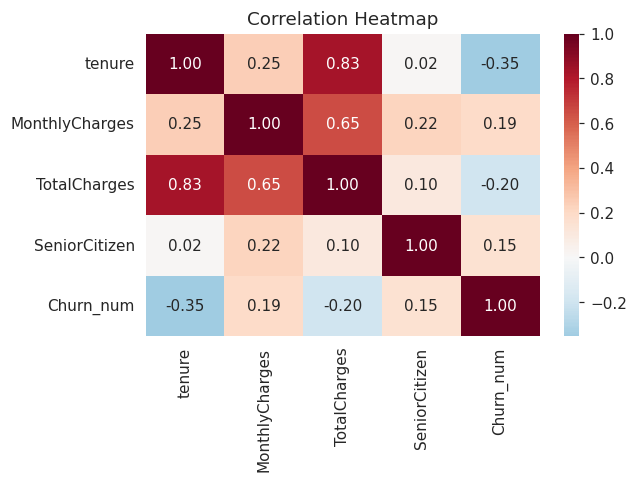

In [15]:
# Correlation of numeric columns (with churn as 0/1)
tmp = df.copy()
tmp["Churn_num"] = (tmp["Churn"] == "Yes").astype(int)
corr = tmp[["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen", "Churn_num"]].corr()
plt.figure(figsize=(6, 4.5))
sns.heatmap(corr, annot=True, cmap="RdBu_r", center=0, fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout(); plt.show()

**EDA observations**
- About **26.5%** of customers churned: the data is imbalanced.
- **Month-to-month** contract customers churn far more (~43%) than One-year (~11%) or Two-year (~3%).
- **Fiber optic** customers churn more (~42%) than DSL (~19%) or no internet (~7%).
- Customers paying by **Electronic check** churn the most (~45%).
- Churners have **short tenure** (many leave in the first months) and **higher monthly charges**.
- Customers **without Tech Support** churn much more.

## Step 4: Feature Engineering and Encoding

In [16]:
# 4.1 Create new features
addon_cols = ["PhoneService"] + service_cols
df["num_services"] = (df[addon_cols] == "Yes").sum(axis=1) + (df["InternetService"] != "No").astype(int)
df["tenure_group"] = pd.cut(df["tenure"], bins=[-1, 12, 24, 48, 72],
                            labels=["0-12m", "13-24m", "25-48m", "49-72m"]).astype(str)

print(df[["tenure", "tenure_group", "num_services"]].head())
print()
print(df.groupby("tenure_group")["Churn"].apply(lambda s: round((s == "Yes").mean()*100, 1)))

   tenure tenure_group  num_services
0       1        0-12m             2
1      34       25-48m             4
2       2        0-12m             4
3      45       25-48m             4
4       2        0-12m             2

tenure_group
0-12m     47.4
13-24m    28.7
25-48m    20.4
49-72m     9.5
Name: Churn, dtype: float64


In [17]:
# 4.2 Encoding categorical data
# (a) Binary Yes/No columns and gender -> 0/1
binary_cols = ["Partner", "Dependents", "PhoneService", "PaperlessBilling"] + service_cols
for c in binary_cols:
    df[c] = (df[c] == "Yes").astype(int)
df["gender"] = (df["gender"] == "Male").astype(int)     # Male=1, Female=0

# (b) Target: Yes -> 1, No -> 0
df["Churn"] = (df["Churn"] == "Yes").astype(int)

# (c) Multi-category columns -> One-Hot Encoding
multi_cols = ["InternetService", "Contract", "PaymentMethod", "tenure_group"]
df_encoded = pd.get_dummies(df, columns=multi_cols).astype(float)

print("Encoded shape:", df_encoded.shape)
df_encoded.head()

Encoded shape: (7043, 32)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,num_services,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group_0-12m,tenure_group_13-24m,tenure_group_25-48m,tenure_group_49-72m
0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,29.85,29.85,0.0,2.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0,34.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,56.95,1889.50,0.0,4.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,2.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,53.85,108.15,1.0,4.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
3,1.0,0.0,0.0,0.0,45.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,42.30,1840.75,0.0,4.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.0,0.0,0.0,0.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,70.70,151.65,1.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0


In [18]:
# 4.3 Separate input features X and target y
X = df_encoded.drop(columns="Churn")
y = df_encoded["Churn"].astype(int)

print("X shape:", X.shape, "| y shape:", y.shape)
print()
print("Feature columns:")
print(list(X.columns))

X shape: (7043, 31) | y shape: (7043,)

Feature columns:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'num_services', 'InternetService_DSL', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_Month-to-month', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Bank transfer (automatic)', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'tenure_group_0-12m', 'tenure_group_13-24m', 'tenure_group_25-48m', 'tenure_group_49-72m']


## Step 5: Training and Testing

In [19]:
# 5.1 Split: 80% train, 20% test. stratify keeps the same churn ratio in both parts
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Churn rate train:", round(y_train.mean()*100, 1), "% | test:", round(y_test.mean()*100, 1), "%")

Train: (5634, 31) | Test: (1409, 31)
Churn rate train: 26.5 % | test: 26.5 %


In [20]:
# 5.2 Scale numeric columns (fit ONLY on train data to avoid data leakage)
num_cols = ["tenure", "MonthlyCharges", "TotalCharges", "num_services"]
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols]  = scaler.transform(X_test[num_cols])
X_train[num_cols].describe().round(2)

,tenure,MonthlyCharges,TotalCharges,num_services
count,5634.00,5634.00,5634.00,5634.00
mean,-0.00,-0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00
min,-1.32,-1.54,-1.01,-1.36
25%,-0.96,-0.97,-0.83,-0.93
50%,-0.14,0.18,-0.40,-0.07
75%,0.92,0.83,0.67,0.79
max,1.61,1.79,2.80,2.08


In [21]:
# 5.3 Train three classification models
# class_weight="balanced" gives more importance to the minority class (churners)
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, min_samples_leaf=20,
                                            class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_leaf=5,
                                            class_weight="balanced", random_state=42, n_jobs=-1),
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{name} trained")

Logistic Regression trained
Decision Tree trained
Random Forest trained


**Why these models?**
- **Logistic Regression:** simple, fast, easy to explain: a good baseline for yes/no problems.
- **Decision Tree:** learns simple if-then rules; very easy to understand.
- **Random Forest:** many trees voting together: usually more accurate and less likely to overfit than one tree.

## Step 6: Model Evaluation

In [22]:
rows = []
preds, probs = {}, {}
for name, model in models.items():
    p  = model.predict(X_test)
    pr = model.predict_proba(X_test)[:, 1]
    preds[name], probs[name] = p, pr
    rows.append({
        "Model": name,
        "Accuracy":  accuracy_score(y_test, p),
        "Precision": precision_score(y_test, p),
        "Recall":    recall_score(y_test, p),
        "F1-Score":  f1_score(y_test, p),
        "ROC-AUC":   roc_auc_score(y_test, pr),
    })
results = pd.DataFrame(rows).set_index("Model").round(3)
results

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.732,0.497,0.791,0.611,0.842
Decision Tree,0.757,0.528,0.791,0.633,0.835
Random Forest,0.764,0.537,0.786,0.638,0.845


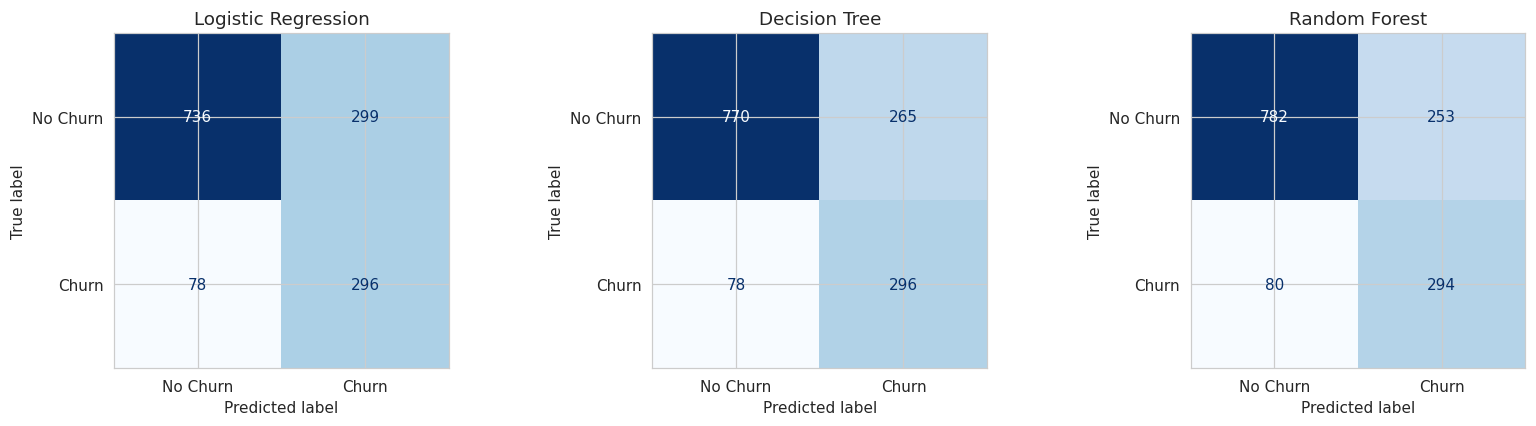

In [23]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for a, (name, p) in zip(ax, preds.items()):
    cm = confusion_matrix(y_test, p)
    ConfusionMatrixDisplay(cm, display_labels=["No Churn", "Churn"]).plot(ax=a, cmap="Blues", colorbar=False)
    a.set_title(name)
plt.tight_layout(); plt.show()

In [24]:
for name, p in preds.items():
    print("=" * 55)
    print(name)
    print(classification_report(y_test, p, target_names=["No Churn", "Churn"]))

Logistic Regression
              precision    recall  f1-score   support

    No Churn       0.90      0.71      0.80      1035
       Churn       0.50      0.79      0.61       374

    accuracy                           0.73      1409
   macro avg       0.70      0.75      0.70      1409
weighted avg       0.80      0.73      0.75      1409

Decision Tree
              precision    recall  f1-score   support

    No Churn       0.91      0.74      0.82      1035
       Churn       0.53      0.79      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.76      0.77      1409

Random Forest
              precision    recall  f1-score   support

    No Churn       0.91      0.76      0.82      1035
       Churn       0.54      0.79      0.64       374

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81   

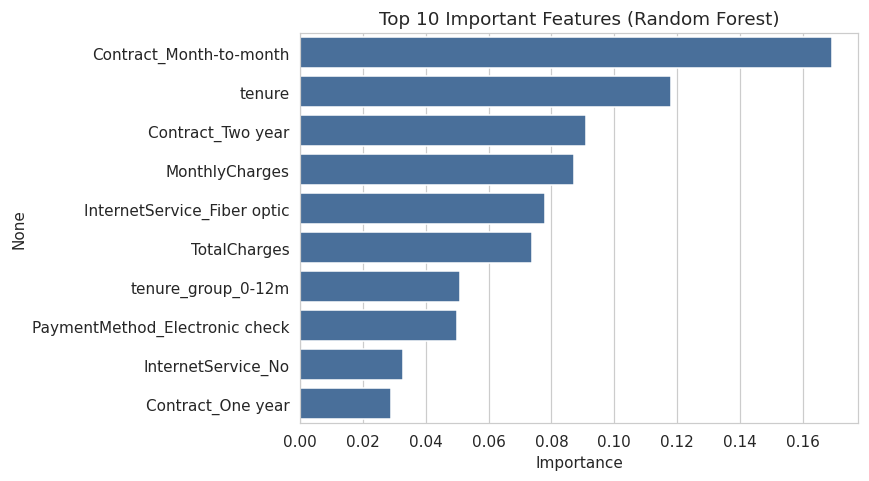

In [25]:
# Which features matter most? (Random Forest importance)
rf = models["Random Forest"]
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
plt.figure(figsize=(8, 4.5))
sns.barplot(x=imp.values, y=imp.index, color="#3B6EA8")
plt.title("Top 10 Important Features (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout(); plt.show()

### Model comparison: which is better and why?

| Model | Accuracy | Precision | Recall | F1 | ROC-AUC |
|---|---|---|---|---|---|
| Logistic Regression | 0.732 | 0.497 | 0.791 | 0.611 | 0.842 |
| Decision Tree | 0.757 | 0.528 | 0.791 | 0.633 | 0.835 |
| **Random Forest** | **0.764** | **0.537** | 0.786 | **0.638** | **0.845** |

**How to read the metrics (churn = positive class)**
- **Accuracy:** overall % of correct predictions.
- **Precision:** of the customers we *predicted* would leave, how many really left.
- **Recall:** of the customers who *really* left, how many we caught. This matters most for churn, because missing a leaving customer costs money.
- **F1-Score:** balance between precision and recall.

**Result:** Random Forest is the best model. It has the highest Accuracy, Precision, F1 and ROC-AUC, while its Recall (about 79%) is almost the same as the other two.
It is better because many trees voting together capture non-linear patterns (for example the mix of contract type, tenure and internet service) and are less sensitive to noise than a single tree.
The confusion matrix for Random Forest shows 294 of 374 real churners caught (80 missed) and 782 of 1035 loyal customers correctly identified (253 false alarms).

*Note:* accuracy looks lower than a plain model would give (about 80%) because we used `class_weight="balanced"`. We deliberately traded some accuracy for much higher **recall** so that fewer real churners are missed.

## Step 7: Application / Prediction on New Customers

In [26]:
# Final model chosen after comparison
final_model = models["Random Forest"]
feature_columns = list(X.columns)

def predict_churn(customer: dict, model=final_model):
    """Takes ONE customer's raw information (a dictionary) and returns Churn / No Churn."""
    c = pd.DataFrame([customer])

    # same cleaning as training
    c["TotalCharges"] = pd.to_numeric(c["TotalCharges"], errors="coerce").fillna(0)
    for col in service_cols:
        c[col] = c[col].replace({"No internet service": "No", "No phone service": "No"})

    # same feature engineering as training
    c["num_services"] = (c[addon_cols] == "Yes").sum(axis=1) + (c["InternetService"] != "No").astype(int)
    c["tenure_group"] = pd.cut(c["tenure"], bins=[-1, 12, 24, 48, 72],
                               labels=["0-12m", "13-24m", "25-48m", "49-72m"]).astype(str)

    # same encoding as training
    for col in binary_cols:
        c[col] = (c[col] == "Yes").astype(int)
    c["gender"] = (c["gender"] == "Male").astype(int)
    c = pd.get_dummies(c, columns=multi_cols)
    c = c.reindex(columns=feature_columns, fill_value=0).astype(float)   # match training columns
    c[num_cols] = scaler.transform(c[num_cols])                          # same scaling

    prob = model.predict_proba(c)[0, 1]
    label = "Churn" if model.predict(c)[0] == 1 else "No Churn"
    return label, round(prob * 100, 1)

In [27]:
# Sample customer 1: new, month-to-month, fiber, pays by electronic check (high-risk profile)
customer_1 = {
    "gender": "Female", "SeniorCitizen": 0, "Partner": "No", "Dependents": "No",
    "tenure": 2, "PhoneService": "Yes", "MultipleLines": "No",
    "InternetService": "Fiber optic", "OnlineSecurity": "No", "OnlineBackup": "No",
    "DeviceProtection": "No", "TechSupport": "No", "StreamingTV": "Yes", "StreamingMovies": "Yes",
    "Contract": "Month-to-month", "PaperlessBilling": "Yes", "PaymentMethod": "Electronic check",
    "MonthlyCharges": 95.5, "TotalCharges": 190.0,
}
# Sample customer 2: long-term, two-year contract, DSL, has security & support (low-risk profile)
customer_2 = {
    "gender": "Male", "SeniorCitizen": 0, "Partner": "Yes", "Dependents": "Yes",
    "tenure": 60, "PhoneService": "Yes", "MultipleLines": "Yes",
    "InternetService": "DSL", "OnlineSecurity": "Yes", "OnlineBackup": "Yes",
    "DeviceProtection": "Yes", "TechSupport": "Yes", "StreamingTV": "No", "StreamingMovies": "No",
    "Contract": "Two year", "PaperlessBilling": "No", "PaymentMethod": "Bank transfer (automatic)",
    "MonthlyCharges": 64.0, "TotalCharges": 3840.0,
}
# Sample customer 3: middle-of-the-road customer
customer_3 = {
    "gender": "Male", "SeniorCitizen": 1, "Partner": "No", "Dependents": "No",
    "tenure": 14, "PhoneService": "Yes", "MultipleLines": "No",
    "InternetService": "Fiber optic", "OnlineSecurity": "No", "OnlineBackup": "Yes",
    "DeviceProtection": "No", "TechSupport": "No", "StreamingTV": "No", "StreamingMovies": "No",
    "Contract": "One year", "PaperlessBilling": "Yes", "PaymentMethod": "Credit card (automatic)",
    "MonthlyCharges": 78.0, "TotalCharges": 1092.0,
}

for i, cust in enumerate([customer_1, customer_2, customer_3], 1):
    label, prob = predict_churn(cust)
    print(f"Customer {i}: Prediction = {label:9s} | Churn probability = {prob}%")

Customer 1: Prediction = Churn     | Churn probability = 88.4%
Customer 2: Prediction = No Churn  | Churn probability = 3.3%
Customer 3: Prediction = No Churn  | Churn probability = 28.3%


In [28]:
# Sanity check: run the function on 6 REAL customers taken from the TEST set (unseen by the model) and compare with the truth
raw = pd.read_csv(csv_path) if not os.path.exists(xlsx_path) else pd.read_excel(xlsx_path)
sample = raw.loc[y_test.sample(6, random_state=7).index]
for _, r in sample.iterrows():
    cust = r.drop(["customerID", "Churn"]).to_dict()
    label, prob = predict_churn(cust)
    print(f"{r['customerID']} | Actual: {r['Churn']:3s} | Predicted: {label:9s} | Probability: {prob}%")

3422-LYEPQ | Actual: Yes | Predicted: Churn     | Probability: 88.4%
2541-YGPKE | Actual: No  | Predicted: No Churn  | Probability: 18.3%
5339-PXDVH | Actual: No  | Predicted: Churn     | Probability: 76.1%
2694-CIUMO | Actual: No  | Predicted: Churn     | Probability: 75.4%
8409-WQJUX | Actual: No  | Predicted: No Churn  | Probability: 14.4%
3908-BLSYF | Actual: Yes | Predicted: Churn     | Probability: 81.7%


## Final Conclusion

**Best model:** Random Forest (Accuracy about 76%, Recall about 79%, F1 about 0.64, ROC-AUC about 0.845).

**Important observations from the data**
- About 27% of customers churn, so the dataset is imbalanced.
- Highest churn risk: **month-to-month contracts**, **short tenure (first 12 months, 47% churn)**, **fiber optic** internet, **electronic check** payment, **no Tech Support / Online Security**, and higher monthly charges.
- Lowest churn risk: **two-year contracts**, long tenure and customers using several add-on services.
- The most important features for the Random Forest were contract type, tenure, monthly charges and internet service.

**Limitations**
- Precision is only about 54%: roughly half of the customers flagged as "will churn" are false alarms.
- The dataset is a single snapshot of about 7,000 customers with no information about time, complaints, competitor offers or customer satisfaction.
- The model shows *correlation*, not *cause* (for example, fiber optic customers may leave because of price or service quality; the data cannot tell us).
- Results were measured on one train/test split; cross-validation and hyper-parameter tuning could improve reliability.

**How a telecom company can use it**
- Score all customers every month and give the retention team a list of high-risk customers.
- Offer targeted discounts, contract upgrades (month-to-month to yearly) or free Tech Support to the risky group.
- Give special attention to new customers in their first months, and encourage automatic payment methods.
- Because retaining a customer is usually cheaper than acquiring a new one, even a moderately accurate model can save money.